# Modelo base — versión simplificada

**Qué busca este notebook.** Probar un primer modelo de aprendizaje automático que predice la
**cantidad de siniestros por día** en un municipio de Montevideo, y compararlo contra
**referencias simples** (línea base) bajo las mismas reglas.

**Pasos:**

1. Cargar la serie diaria que exporta el ETL.
2. Tomar del diagnóstico lo que hace falta para el modelo.
3. Separar entrenamiento (80 %) y prueba (20 % final), respetando el orden en el tiempo.
4. Entrenar un árbol de decisión que predice a partir de días anteriores.
5. Construir la línea base.
6. Comparar: primero en una semana, después en **todo** el conjunto de prueba.

> **Sin variables exógenas.** En esta entrega los modelos usan **solo la historia de la propia
> serie** (los siniestros de días anteriores). El calendario (tipo de día, feriados) y el clima
> quedan para una etapa posterior.

> **Sin análisis exploratorio propio.** La tendencia, el patrón semanal y la autocorrelación de esta
> misma serie ya están en `notebooks/diagnostico_datos_municipio.ipynb`. Acá no se recalculan: la
> sección 2 resume lo que se usa, con la tabla de donde sale cada cifra.

> **Alcance.** Trabaja una sola serie: MUNICIPIO C, el municipio con más siniestros registrados.
> Sirve para fijar el procedimiento, **no** para afirmar que el modelo funciona en toda Montevideo.

Tablas y figuras: `experiments/base_2/`. Resumen para el informe: `documentacion/resumen_base_2.md`.

## 0. Entorno

`skforecast` no está en `requirements.txt`, así que se instala desde el notebook, con la versión
usada en la corrida. **Ojo:** `skforecast` 0.25 exige pandas menor a 3, y `requirements.txt` fija
pandas 3.0.5; instalarlo baja pandas a la serie 2.x. Es una decisión pendiente del equipo
(`HANDOFF.md`). Las versiones efectivas de cada corrida quedan en `tablas/00_entorno.csv`.

In [1]:
# skforecast no está en requirements.txt: lo instalamos en el entorno del kernel.
%pip install skforecast==0.25.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Rutas, fechas y utilidades
from pathlib import Path
from datetime import datetime
import platform
from IPython.display import display

# Visualización
import matplotlib
import matplotlib.pyplot as plt

# Modelo y métricas
import sklearn
import skforecast
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_poisson_deviance, mean_absolute_error, mean_squared_error
from skforecast.recursive import ForecasterRecursive

# Semilla global: el árbol de decisión la usa como random_state.
SEMILLA = 42
np.random.seed(SEMILLA)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

versiones = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "scikit-learn": sklearn.__version__,
    "skforecast": skforecast.__version__,
}
for nombre, version in versiones.items():
    print(f"{nombre:13s}", version)

python        3.13.2
pandas        2.3.3
numpy         2.5.2
matplotlib    3.11.1
scikit-learn  1.9.0
skforecast    0.25.0


In [3]:
# Ubicamos la raíz del repositorio: el notebook puede ejecutarse desde la raíz
# (VS Code) o desde la carpeta notebooks/ (jupyter nbconvert).
_cwd = Path.cwd()
RAIZ = _cwd if (_cwd / "data").exists() else _cwd.parent

RUTA_DATOS = RAIZ / "data" / "processed" / "panel_zona_top.csv"
DIR_TABLAS = RAIZ / "experiments" / "base_2" / "tablas"
DIR_FIGURAS = RAIZ / "experiments" / "base_2" / "figuras"
DIR_TABLAS.mkdir(parents=True, exist_ok=True)
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)


def guardar_tabla(tabla, nombre):
    """Guarda una tabla en experiments/base_2/tablas/."""
    ruta = DIR_TABLAS / nombre
    tabla.to_csv(ruta, index=False, encoding="utf-8")
    print("tabla guardada :", ruta.relative_to(RAIZ).as_posix())


def guardar_figura(fig, nombre):
    """Guarda una figura en experiments/base_2/figuras/."""
    ruta = DIR_FIGURAS / nombre
    fig.savefig(ruta, bbox_inches="tight")
    print("figura guardada:", ruta.relative_to(RAIZ).as_posix())


entorno = pd.DataFrame({"componente": list(versiones), "version": list(versiones.values())})
entorno.loc[len(entorno)] = ["fecha_ejecucion", datetime.now().strftime("%Y-%m-%d %H:%M")]
guardar_tabla(entorno, "00_entorno.csv")

tabla guardada : experiments/base_2/tablas/00_entorno.csv


## 1. Carga de datos

`data/processed/panel_zona_top.csv` lo genera el ETL (`notebooks/preparacion_montevideo.ipynb`):
una fila por día para el municipio con más siniestros. La variable a predecir es `n_siniestros`,
la cantidad de siniestros registrados ese día.

El archivo trae además `tipo_dia` y variables de clima. **No se cargan**: se leen solo la fecha, el
municipio y `n_siniestros`, así ningún modelo puede usar una variable exógena por error.

> Este archivo **no debe abrirse y guardarse desde Excel**: Excel lo reescribe con `;` y fechas
> `dd/mm/aaaa`, y el notebook deja de leerlo.

In [4]:
# Solo leemos la fecha, el municipio y la variable a predecir: nada de calendario ni clima.
# La fecha es el índice. Se lee con formato explícito: si pandas lo adivina,
# una fecha escrita como 01/07/2021 puede leerse como 7 de enero sin avisar.
df = pd.read_csv(RUTA_DATOS, index_col="fecha", usecols=["fecha", "zona_id", "n_siniestros"])
df.index = pd.to_datetime(df.index, format="%Y-%m-%d")

MUNICIPIO = df["zona_id"].iloc[0]
print("Municipio:", MUNICIPIO)
df.head()

Municipio: MUNICIPIO C


,zona_id,n_siniestros
fecha,,
2021-07-01,MUNICIPIO C,5
2021-07-02,MUNICIPIO C,8
2021-07-03,MUNICIPIO C,2
2021-07-04,MUNICIPIO C,4
2021-07-05,MUNICIPIO C,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1645 entries, 2021-07-01 to 2025-12-31
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   zona_id       1645 non-null   object
 1   n_siniestros  1645 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 38.6+ KB


In [6]:
# Revisamos desde cuándo hasta cuándo llega la serie temporal.
# Como "fecha" es el índice, usamos df.index.min() y df.index.max().
df.index.min(), df.index.max()

(Timestamp('2021-07-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [7]:
# Calculamos la diferencia de tiempo entre cada observación y la anterior.
# Luego contamos cuántas veces aparece cada separación temporal.
df.index.to_series().diff().value_counts().head()

fecha
1 days    1644
Name: count, dtype: int64

**Lectura.** La serie tiene 1.645 días, del 2021-07-01 al 2025-12-31, y cada fecha está exactamente a
1 día de la anterior (1.644 diferencias de 1 día): **no faltan días**. Ninguna columna tiene valores
nulos. Solo quedaron cargadas `zona_id` y `n_siniestros`: el calendario y el clima no están en memoria.
Son los mismos 1.645 días que analiza el diagnóstico (tabla `04_resumen_serie_municipio_c`).

## 2. Lo que se toma del diagnóstico

`notebooks/diagnostico_datos_municipio.ipynb` ya estudió la estructura temporal de esta misma serie
(MUNICIPIO C, 2021-07-01 a 2025-12-31). No se repite acá. Estos son los resultados que usa este
notebook; las tablas están en `experiments/diagnostico_datos_municipio/tablas/`.

| Resultado del diagnóstico | Tabla | Qué implica acá |
| --- | --- | --- |
| Hay un patrón semanal claro: el viernes promedia 4,268 siniestros y el domingo 2,038. | `06_perfil_semanal` | Es la estructura principal de la serie. Sin calendario, solo se puede captar con días de semanas anteriores. |
| La autocorrelación sale de la banda de azar (±0,0483) en los rezagos 1 (0,0785), 7 (0,0764), 14 (0,1706), 21 (0,1099) y 28 (0,1125); apenas, también en 15 y 29. | `08_acf_pacf_crudo` | Los rezagos del árbol son 1, 7, 14 y 21 (sección 4). La línea base usa 7, 14, 21 y 28 (sección 5). |
| Al descontar el calendario, el rezago 1 sigue fuera de la banda (0,0745) y los rezagos 7, 21 y 28 quedan dentro. | `09_acf_residuo_calendario` | El rezago de 1 día trae algo propio; los de 7, 21 y 28 días traen sobre todo el patrón semanal. |
| Todas las autocorrelaciones son débiles: la más alta es 0,1706. | `08_acf_pacf_crudo` | Hay que esperar poca ganancia de los días anteriores. |
| No conviene diferenciar ni transformar la serie: diferenciar lleva la autocorrelación a 1 día a −0,4621. | `12_estacionariedad_adf_kpss`, `13_efecto_diferenciacion`, `14_diagnostico_transformacion` | Se predice `n_siniestros` tal cual. |
| El nivel cambia entre años: 3,3288 siniestros por día en 2023 y 3,7562 en 2025. | `05_tendencia_anual` | Un modelo que aprende un nivel fijo va a predecir de menos en la prueba (sección 3). |

> **Cuidado.** El diagnóstico usó la serie completa, incluido el período que acá es de prueba. Elegir
> los rezagos con esa evidencia es una **fuga de información leve**: ningún valor se ajusta con la
> prueba, pero la elección no se hizo solo con entrenamiento.

## 3. Entrenamiento y prueba

En una serie temporal los días no se mezclan al azar: el modelo aprende con el **pasado** y se
evalúa sobre el **futuro**, como pasaría si se usara de verdad. Se reserva el **20 % final** como
conjunto de prueba.

**Regla desde acá:** todo promedio o ajuste se calcula **solo con entrenamiento**. La prueba se usa
únicamente para evaluar, en las secciones 6 y 7.

In [8]:
# Definimos el tamaño del conjunto de prueba: el 20% final de la serie.
n_test = int(len(df) * 0.2)

# Partición temporal: el pasado entrena, el futuro evalúa.
train = df.iloc[:-n_test].copy()
test = df.iloc[-n_test:].copy()

particion = pd.DataFrame({
    "conjunto": ["entrenamiento", "prueba"],
    "desde": [train.index.min().date(), test.index.min().date()],
    "hasta": [train.index.max().date(), test.index.max().date()],
    "dias": [len(train), len(test)],
    "porcentaje": [round(100 * len(train) / len(df), 1), round(100 * len(test) / len(df), 1)],
    # Descriptivo: no se usa para ajustar nada.
    "promedio_siniestros_por_dia": [round(train["n_siniestros"].mean(), 3), round(test["n_siniestros"].mean(), 3)],
})
guardar_tabla(particion, "01_particion.csv")
particion

tabla guardada : experiments/base_2/tablas/01_particion.csv


,conjunto,desde,hasta,dias,porcentaje,promedio_siniestros_por_dia
0,entrenamiento,2021-07-01,2025-02-05,1316,80.0,3.426
1,prueba,2025-02-06,2025-12-31,329,20.0,3.875


figura guardada: experiments/base_2/figuras/fig1_particion.png


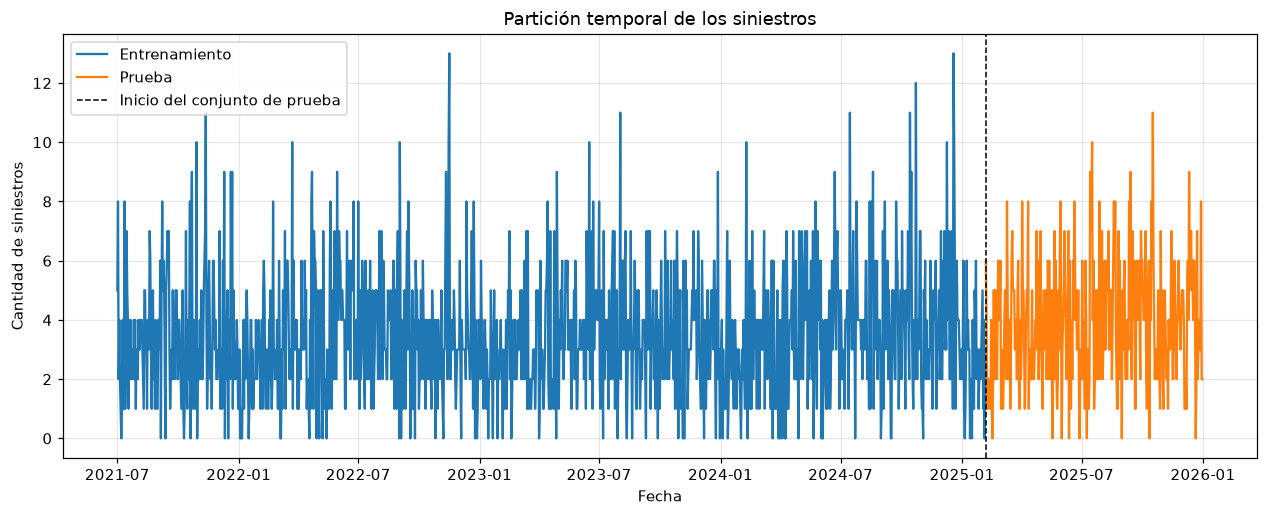

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index, train["n_siniestros"], color="tab:blue", label="Entrenamiento")
ax.plot(test.index, test["n_siniestros"], color="tab:orange", label="Prueba")
ax.axvline(test.index.min(), color="black", linestyle="--", linewidth=1,
           label="Inicio del conjunto de prueba")

ax.set_title("Partición temporal de los siniestros")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de siniestros")
ax.legend()
guardar_figura(fig, "fig1_particion.png")
plt.show()

**Lectura** (tabla `01_particion`, figura `fig1_particion`). Entrenamiento: 1.316 días (2021-07-01 →
2025-02-05). Prueba: 329 días (2025-02-06 → 2025-12-31).

**Dato importante para después:** la prueba promedia **3,875** siniestros por día y el entrenamiento
**3,426**, un 13 % más. Coincide con lo que mostró el diagnóstico: el nivel de la serie subió en 2024
y 2025. Un modelo que aprende un nivel fijo del pasado va a tender a **predecir de menos** en la
prueba. El promedio de prueba se muestra solo como descripción: no se usa para ajustar nada.

## 4. Modelo: árbol de decisión con `skforecast`

`ForecasterRecursive` convierte la serie en una tabla: para cada día, las variables son los
siniestros de **1, 7, 14 y 21 días antes** (`lags=[1, 7, 14, 21]`) y el objetivo es el siniestro de
ese día. Sobre esa tabla se entrena un **árbol de decisión**, que aprende reglas del tipo «si hace 7
días hubo más de 5 siniestros y ayer menos de 2, predecir 4».

**No recibe variables exógenas:** se entrena con `fit(y=...)`, sin el argumento `exog`. Como el
modelo no sabe qué día de la semana es, el patrón semanal solo le puede llegar por los rezagos de 7,
14 y 21 días (sección 2).

Para predecir más de un día hacia adelante, el modelo usa su propia predicción como si fuera un
dato observado (**predicción recursiva**). Con estos rezagos eso solo afecta al rezago de 1 día: en
una semana, los valores de 7, 14 y 21 días antes siempre están observados.

`max_depth=15` se fijó a mano. Elegir la profundidad con datos de validación es trabajo del
Entregable 3; acá se registra el tamaño del árbol, que indica si **aprende patrones** o **memoriza
días**.

In [10]:
forecaster = ForecasterRecursive(
    estimator=DecisionTreeRegressor(
        max_depth=15,
        random_state=SEMILLA
    ),
    lags=[1, 7, 14, 21]  # Siniestros de 1, 7, 14 y 21 días antes
)

# skforecast necesita que el índice tenga una frecuencia explícita.
frecuencia = pd.infer_freq(train.index)
if frecuencia is None:
    raise ValueError("No se pudo inferir la frecuencia temporal del índice de train.")

y_train = train["n_siniestros"].asfreq(frecuencia)
y_test = test["n_siniestros"].asfreq(frecuencia)

# Verificamos que fijar la frecuencia no haya creado días faltantes.
if y_train.isna().any() or y_test.isna().any():
    raise ValueError("El índice contiene fechas faltantes después de establecer la frecuencia.")

# Solo la serie objetivo: sin exog.
forecaster.fit(y=y_train)
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: DecisionTreeRegressor 
Lags: [ 1  7 14 21] 
Window features: None 
Calendar features: None 
Window size: 21 
Series name: n_siniestros 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2021-07-01 00:00:00'), Timestamp('2025-02-05 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 15,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2026-09-15 13:34:33 
Last fit date: 2026-09-15 13:34:33 
Skforecast version: 0.25.0 
Python version: 3.13.2 
Forecaster id: None

In [11]:
# ¿Con qué variables se entrenó? Deben ser solo rezagos de la serie.
print("Variables del árbol:", forecaster.X_train_features_names_out_)
print("¿Usa variables exógenas?:", forecaster.exog_in_)

# ¿Aprende patrones o memoriza días? Comparamos la cantidad de hojas con las filas de entrenamiento.
# Los primeros 21 días no tienen el rezago de 21 días, así que no entran a la tabla de entrenamiento.
arbol = forecaster.estimator
filas_ajuste = len(y_train) - forecaster.window_size

tamano_arbol = pd.DataFrame({
    "indicador": ["filas de entrenamiento", "profundidad", "hojas", "filas por hoja (promedio)"],
    "valor": pd.Series([filas_ajuste, arbol.get_depth(), arbol.get_n_leaves(),
                        round(filas_ajuste / arbol.get_n_leaves(), 2)], dtype="object"),
})
guardar_tabla(tamano_arbol, "02_tamano_arbol.csv")
tamano_arbol

Variables del árbol: ['lag_1', 'lag_7', 'lag_14', 'lag_21']
¿Usa variables exógenas?: False
tabla guardada : experiments/base_2/tablas/02_tamano_arbol.csv


,indicador,valor
0,filas de entrenamiento,1295
1,profundidad,15
2,hojas,716
3,filas por hoja (promedio),1.81


**Lectura** (tabla `02_tamano_arbol`). El árbol se entrenó solo con `lag_1`, `lag_7`, `lag_14` y
`lag_21`, sin variables exógenas. Tiene **716 hojas para 1.295 filas** de entrenamiento: en promedio,
**1,81 días por hoja**. Cada hoja es casi un día concreto del pasado, así que el árbol **memoriza**
días en lugar de aprender reglas generales. Es esperable que acierte con los datos que vio y falle con
los nuevos; la sección 7 lo comprueba.

## 5. Línea base

Un modelo solo es útil si mejora algo más simple. Se construyen tres referencias. **Ninguna usa
variables exógenas**: todas predicen con los siniestros ya observados de la propia serie.

| Referencia | Qué predice |
| --- | --- |
| **Media constante** | El promedio de entrenamiento, todos los días. Es el piso. |
| **Repetir semana anterior** | Lo que pasó 7 días antes. La referencia más habitual en series temporales. |
| **Promedio de las últimas 4 semanas** ← *línea base* | El promedio de lo que pasó 7, 14, 21 y 28 días antes: los últimos cuatro días iguales de la semana (para un viernes, los cuatro viernes anteriores). |

**Por qué esa es la línea base.** Se eligió antes de mirar ningún resultado de prueba:

1. Usa solo la propia serie, como el árbol.
2. Recoge el patrón semanal que muestra el diagnóstico (sección 2): un viernes se predice con viernes.
3. Promedia cuatro semanas en lugar de copiar una sola, así que el ruido de una semana pesa menos.
4. Avanza con el tiempo, así que sigue los cambios de nivel de la serie. La media constante no puede.

El 4 no se ajustó: es aproximadamente un mes. Reemplaza al «promedio por tipo de día» de la versión
anterior, que usaba `tipo_dia`.

In [12]:
ARBOL = "Árbol de decisión"
LINEA_BASE = "Promedio de las últimas 4 semanas (línea base)"
MODELOS = [ARBOL, "Media constante", LINEA_BASE, "Repetir semana anterior"]

# La media constante se calcula solo con entrenamiento.
media_train = y_train.mean()
print("Media de entrenamiento:", round(media_train, 3))

# Serie completa con frecuencia diaria: las referencias y el árbol
# necesitan los días ya observados antes de cada fecha a predecir.
serie_completa = df["n_siniestros"].asfreq(frecuencia)

# Promedio de lo observado 7, 14, 21 y 28 días antes de cada fecha.
# Al predecir una semana, esos cuatro días siempre son anteriores a la semana: ya están observados.
promedio_4_semanas = (serie_completa.shift(7) + serie_completa.shift(14)
                      + serie_completa.shift(21) + serie_completa.shift(28)) / 4


def predecir_referencias(fechas):
    """Predicciones de las tres referencias simples para las fechas indicadas."""
    return {
        "Media constante": pd.Series(media_train, index=fechas),
        LINEA_BASE: promedio_4_semanas.loc[fechas],
        "Repetir semana anterior": serie_completa.shift(7).loc[fechas],
    }

Media de entrenamiento: 3.426


## 6. Primera mirada: la primera semana de prueba

Cada modelo predice los primeros 7 días del conjunto de prueba. Para compararlos se usan cuatro
métricas, calculadas sobre las predicciones sin redondear:

| Métrica | Cómo se lee |
| --- | --- |
| **Desvianza de Poisson media** ← *principal* | El error pensado para conteos: pesa según el nivel esperado. Equivocarse por 1 cuando se esperaba 0,5 pesa más que cuando se esperaba 5. Es la métrica para **comparar y elegir modelos**. 0 = perfecto; menor es mejor. |
| **MAE** | Siniestros de diferencia por día, en promedio. Menor es mejor. |
| **RMSE** | Parecido al MAE, pero castiga más los errores grandes. Menor es mejor. |
| **Total predicho / observado** | 1 = acierta el volumen total. Menor que 1 = predice menos siniestros de los que ocurrieron. |

> La desvianza de Poisson no admite predicciones iguales a 0. Para calcularla, una predicción de 0
> se reemplaza por 0,000001, igual que en `base.ipynb`. Si ese día hubo siniestros, el error queda
> muy grande: la métrica castiga fuerte predecir que no va a pasar nada cuando sí pasa.

In [13]:
# La desvianza de Poisson exige predicciones mayores que 0.
# Solo para esa métrica, los ceros se reemplazan por un valor mínimo (igual que en base.ipynb).
EPS = 1e-6


def calcular_metricas(real, prediccion):
    """Desvianza de Poisson (principal), MAE, RMSE y total predicho sobre total observado."""
    return {
        "desvianza_poisson": mean_poisson_deviance(real, prediccion.clip(lower=EPS)),
        "MAE": mean_absolute_error(real, prediccion),
        "RMSE": np.sqrt(mean_squared_error(real, prediccion)),
        "total_predicho_sobre_observado": prediccion.sum() / real.sum(),
    }


# Horizonte de predicción: los primeros 7 días del conjunto de prueba.
steps = 7
fechas_semana = y_test.index[:steps]

# El árbol predice de forma recursiva a partir de los últimos días de entrenamiento.
pred_arbol = forecaster.predict(steps=steps)
assert pred_arbol.index.equals(fechas_semana), "las fechas predichas no son las de la prueba"

predicciones_semana = pd.DataFrame({
    "valor_real": y_test.loc[fechas_semana],
    ARBOL: pred_arbol,
})
for nombre, prediccion in predecir_referencias(fechas_semana).items():
    predicciones_semana[nombre] = prediccion

guardar_tabla(predicciones_semana.round(3).rename_axis("fecha").reset_index(),
              "03_primera_semana_predicciones.csv")
predicciones_semana.round(2)

tabla guardada : experiments/base_2/tablas/03_primera_semana_predicciones.csv


,valor_real,Árbol de decisión,Media constante,Promedio de las últimas 4 semanas (línea base),Repetir semana anterior
2025-02-06,6,9.00,3.43,2.00,3.0
2025-02-07,4,2.00,3.43,3.75,4.0
2025-02-08,1,3.50,3.43,3.25,5.0
2025-02-09,1,2.00,3.43,1.50,1.0
2025-02-10,2,2.75,3.43,2.75,4.0
2025-02-11,2,3.33,3.43,2.25,0.0
2025-02-12,2,2.38,3.43,3.00,3.0


figura guardada: experiments/base_2/figuras/fig2_primera_semana.png


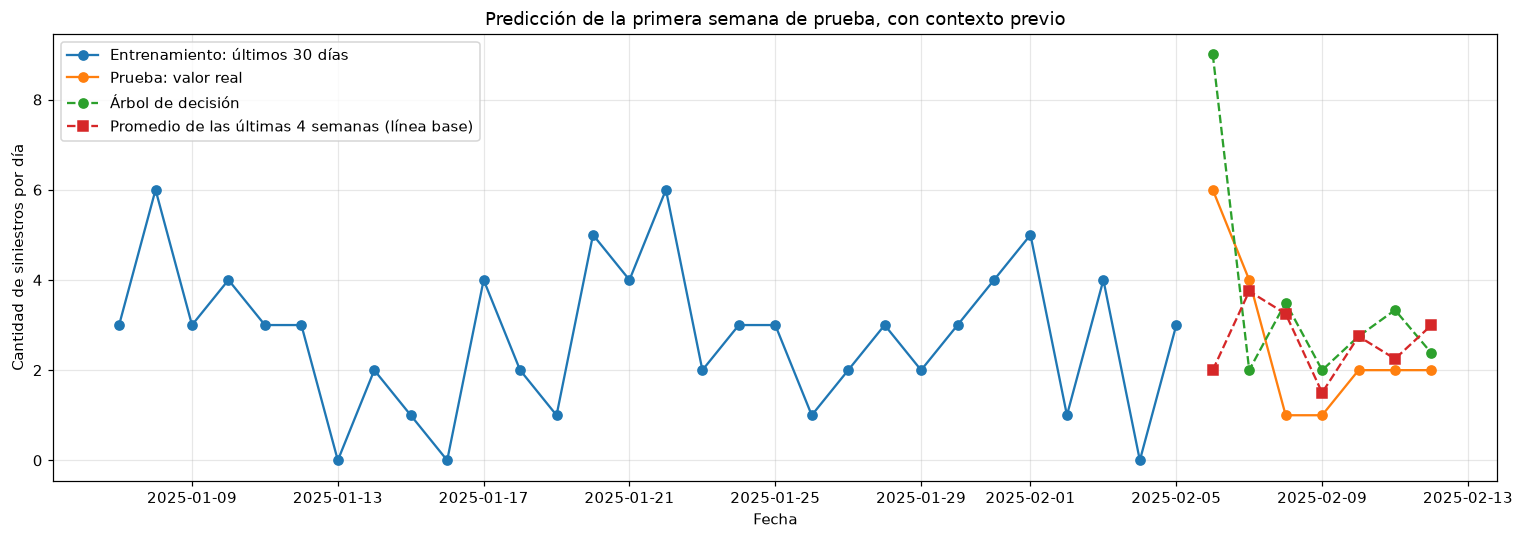

In [14]:
# Contexto: los últimos 30 días de entrenamiento antes de la semana predicha.
dias_contexto = 30
contexto = y_train.iloc[-dias_contexto:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(contexto.index, contexto, marker="o", color="tab:blue", label="Entrenamiento: últimos 30 días")
ax.plot(fechas_semana, predicciones_semana["valor_real"], marker="o", color="tab:orange",
        label="Prueba: valor real")
ax.plot(fechas_semana, predicciones_semana[ARBOL], marker="o", linestyle="--", color="tab:green",
        label=ARBOL)
ax.plot(fechas_semana, predicciones_semana[LINEA_BASE], marker="s", linestyle="--", color="tab:red",
        label=LINEA_BASE)

ax.set_title("Predicción de la primera semana de prueba, con contexto previo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de siniestros por día")
ax.legend()
plt.tight_layout()
guardar_figura(fig, "fig2_primera_semana.png")
plt.show()

In [15]:
metricas_semana = pd.DataFrame([
    {"modelo": m, **calcular_metricas(predicciones_semana["valor_real"], predicciones_semana[m])}
    for m in MODELOS
]).sort_values("desvianza_poisson").round(3)

guardar_tabla(metricas_semana, "04_primera_semana_metricas.csv")
metricas_semana

tabla guardada : experiments/base_2/tablas/04_primera_semana_metricas.csv


,modelo,desvianza_poisson,MAE,RMSE,total_predicho_sobre_observado
0,Árbol de decisión,0.957,1.565,1.802,1.387
2,Promedio de las últimas 4 semanas (línea base),1.166,1.286,1.813,1.028
1,Media constante,1.220,1.754,1.883,1.332
3,Repetir semana anterior,8.963,1.714,2.204,1.111


**Lectura** (tablas `03_primera_semana_predicciones` y `04_primera_semana_metricas`, figura
`fig2_primera_semana`).

| Modelo | Desvianza de Poisson | MAE | Total predicho / observado |
| --- | --- | --- | --- |
| Árbol de decisión | **0,957** | 1,565 | 1,387 |
| Promedio de las últimas 4 semanas (línea base) | 1,166 | **1,286** | **1,028** |
| Media constante | 1,220 | 1,754 | 1,332 |
| Repetir semana anterior | 8,963 | 1,714 | 1,111 |

- **Con la métrica principal, el árbol es el mejor esta semana** (0,957), aunque en MAE queda detrás
  de la línea base (1,565 contra 1,286). Las dos métricas no ordenan igual: la desvianza pesa cada
  error según lo que el modelo esperaba, y castiga más predecir de menos que de más.
- El mayor error del árbol es el primer día: predijo **9 siniestros el jueves 6 de febrero** (hubo 6).
  La línea base predijo 2 ese día: se quedó corta, y eso la desvianza lo castiga más.
- **Repetir la semana anterior tiene una desvianza de 8,963**, sobre todo por un día: predijo 0 el
  martes 11 de febrero y hubo 2. Con esta métrica, predecir 0 cuando ocurre algo cuesta muchísimo.
- **La línea base acierta el volumen de la semana:** predijo 18,5 siniestros y hubo 18.

**Cuidado:** son 7 días, y una semana puede ser atípica, como esta. La sección siguiente repite la
comparación con todas las semanas.

## 7. Evaluación en todo el conjunto de prueba

Una semana no alcanza: con 7 días, el resultado depende mucho de qué semana tocó. Se repite la
evaluación sobre **todas las semanas** del conjunto de prueba:

1. Se parte del primer día de prueba.
2. Cada modelo predice los 7 días siguientes, usando solo lo observado hasta ese momento.
3. Se avanza una semana y se repite, hasta cubrir la prueba completa.

Los modelos **no se reentrenan**: quedan fijos con lo aprendido en entrenamiento, como si se hubieran
puesto en uso el primer día de prueba. Lo único que avanza es la información reciente: los días
observados que usa el árbol como rezagos y las semanas anteriores que usan las referencias.

In [16]:
bloques = []
for inicio in range(0, len(y_test), steps):
    fechas = y_test.index[inicio:inicio + steps]

    # Últimos 21 días observados antes de la semana (de entrenamiento o de semanas de prueba ya pasadas).
    posicion = serie_completa.index.get_loc(fechas[0])
    ultimos_dias = serie_completa.iloc[posicion - forecaster.window_size:posicion]
    pred = forecaster.predict(steps=len(fechas), last_window=ultimos_dias)
    assert pred.index.equals(fechas), "las fechas predichas no coinciden con la semana"

    bloque = pd.DataFrame({"semana": inicio // steps + 1, "valor_real": y_test.loc[fechas], ARBOL: pred})
    for nombre, prediccion in predecir_referencias(fechas).items():
        bloque[nombre] = prediccion
    bloques.append(bloque)

predicciones_test = pd.concat(bloques)
assert len(predicciones_test) == len(y_test) and predicciones_test.notna().all().all()
print("Semanas evaluadas:", predicciones_test["semana"].nunique(), "| días:", len(predicciones_test))

Semanas evaluadas: 47 | días: 329


In [17]:
metricas_test = pd.DataFrame([
    {"modelo": m, **calcular_metricas(predicciones_test["valor_real"], predicciones_test[m])}
    for m in MODELOS
]).sort_values("desvianza_poisson")

# Diferencia contra la línea base, en porcentaje (positivo = peor que la línea base).
desvianza_linea_base = metricas_test.loc[metricas_test["modelo"] == LINEA_BASE, "desvianza_poisson"].iloc[0]
mae_linea_base = metricas_test.loc[metricas_test["modelo"] == LINEA_BASE, "MAE"].iloc[0]
metricas_test["desvianza_vs_linea_base_pct"] = 100 * (metricas_test["desvianza_poisson"] / desvianza_linea_base - 1)
metricas_test["MAE_vs_linea_base_pct"] = 100 * (metricas_test["MAE"] / mae_linea_base - 1)
metricas_test = metricas_test.round({"desvianza_poisson": 3, "MAE": 3, "RMSE": 3,
                                     "total_predicho_sobre_observado": 3,
                                     "desvianza_vs_linea_base_pct": 1, "MAE_vs_linea_base_pct": 1})

# Días en que cada modelo predijo exactamente 0: ahí la desvianza de Poisson castiga mucho.
metricas_test["dias_con_prediccion_cero"] = [int((predicciones_test[m] == 0).sum()) for m in metricas_test["modelo"]]

guardar_tabla(metricas_test, "05_test_metricas.csv")
metricas_test

tabla guardada : experiments/base_2/tablas/05_test_metricas.csv


,modelo,desvianza_poisson,MAE,RMSE,total_predicho_sobre_observado,desvianza_vs_linea_base_pct,MAE_vs_linea_base_pct,dias_con_prediccion_cero
1,Media constante,1.262,1.741,2.120,0.884,-5.2,-0.8,0
2,Promedio de las últimas 4 semanas (línea base),1.332,1.755,2.179,0.981,0.0,0.0,0
0,Árbol de decisión,3.462,2.137,2.738,0.967,159.9,21.8,7
3,Repetir semana anterior,5.007,2.228,2.866,0.996,275.8,27.0,10


In [18]:
# Días en que el árbol predijo 0. Si ese día hubo siniestros, la desvianza de Poisson es muy grande.
predicciones_test.loc[predicciones_test[ARBOL] == 0, ["semana", "valor_real", ARBOL]]

,semana,valor_real,Árbol de decisión
2025-02-16,2,0,0.0
2025-02-27,4,4,0.0
2025-06-22,20,4,0.0
2025-07-24,25,2,0.0
2025-08-03,26,3,0.0
2025-08-31,30,0,0.0
2025-09-07,31,4,0.0


In [19]:
# Control cruzado: la media constante debe dar lo mismo que en base.ipynb,
# que usa la misma partición, la misma evaluación semana a semana y el mismo cálculo de métricas.
ruta_base = RAIZ / "experiments" / "base" / "tablas" / "06_evaluacion_test.csv"
if ruta_base.exists():
    base = pd.read_csv(ruta_base).set_index("modelo")
    media_propia = metricas_test.set_index("modelo").loc["Media constante"]
    media_base = base.loc["Media constante"]
    for metrica, metrica_base in [("desvianza_poisson", "desvianza_poisson"), ("MAE", "mae")]:
        estado = "OK" if abs(media_propia[metrica] - media_base[metrica_base]) < 0.001 else "DIFIERE"
        print(f"{estado}: Media constante {metrica} {media_propia[metrica]:.4f} | "
              f"base.ipynb {media_base[metrica_base]:.4f}")
else:
    print("No está experiments/base/tablas/06_evaluacion_test.csv: control omitido.")

OK: Media constante desvianza_poisson 1.2620 | base.ipynb 1.2625
OK: Media constante MAE 1.7410 | base.ipynb 1.7411


In [20]:
# Error y total por semana, para ver cuánto cambia el resultado según la semana.
filas = []
for semana, grupo in predicciones_test.groupby("semana"):
    fila = {"semana": semana, "desde": grupo.index.min().date(), "observado_total": grupo["valor_real"].sum()}
    for m in MODELOS:
        fila[f"desvianza | {m}"] = mean_poisson_deviance(grupo["valor_real"], grupo[m].clip(lower=EPS))
    for m in MODELOS:
        fila[f"MAE | {m}"] = mean_absolute_error(grupo["valor_real"], grupo[m])
    for m in MODELOS:
        fila[f"total | {m}"] = grupo[m].sum()
    filas.append(fila)
semanal = pd.DataFrame(filas).round(3)
guardar_tabla(semanal, "06_test_semanal.csv")

# La variabilidad se mide con la métrica principal.
variabilidad = pd.DataFrame([{
    "modelo": m,
    "desvianza_semanal_minima": semanal[f"desvianza | {m}"].min(),
    "desvianza_semanal_mediana": semanal[f"desvianza | {m}"].median(),
    "desvianza_semanal_maxima": semanal[f"desvianza | {m}"].max(),
    "semanas_con_menor_desvianza_que_linea_base": (
        pd.NA if m == LINEA_BASE
        else int((semanal[f"desvianza | {m}"] < semanal[f"desvianza | {LINEA_BASE}"]).sum())
    ),
    "semanas": len(semanal),
} for m in MODELOS])
guardar_tabla(variabilidad, "07_test_variabilidad_semanal.csv")
variabilidad

tabla guardada : experiments/base_2/tablas/06_test_semanal.csv
tabla guardada : experiments/base_2/tablas/07_test_variabilidad_semanal.csv


,modelo,desvianza_semanal_minima,desvianza_semanal_mediana,desvianza_semanal_maxima,semanas_con_menor_desvianza_que_linea_base,semanas
0,Árbol de decisión,0.551,2.158,19.339,8,47
1,Media constante,0.318,1.147,2.388,29,47
2,Promedio de las últimas 4 semanas (línea base),0.473,1.209,2.516,<NA>,47
3,Repetir semana anterior,0.322,2.417,34.962,6,47


figura guardada: experiments/base_2/figuras/fig3_test_totales_semanales.png


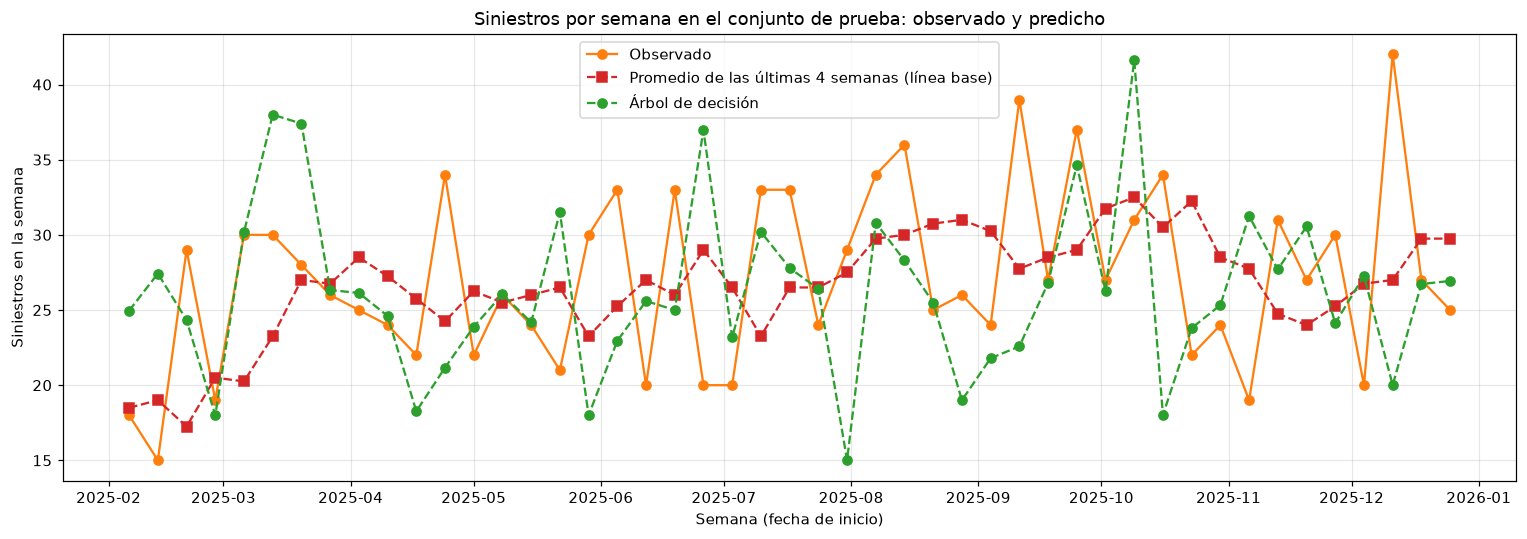

In [21]:
fechas_semanas = pd.to_datetime(semanal["desde"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fechas_semanas, semanal["observado_total"], marker="o", color="tab:orange", label="Observado")
ax.plot(fechas_semanas, semanal[f"total | {LINEA_BASE}"], marker="s", linestyle="--", color="tab:red",
        label=LINEA_BASE)
ax.plot(fechas_semanas, semanal[f"total | {ARBOL}"], marker="o", linestyle="--", color="tab:green",
        label=ARBOL)

ax.set_title("Siniestros por semana en el conjunto de prueba: observado y predicho")
ax.set_xlabel("Semana (fecha de inicio)")
ax.set_ylabel("Siniestros en la semana")
ax.legend()
plt.tight_layout()
guardar_figura(fig, "fig3_test_totales_semanales.png")
plt.show()

figura guardada: experiments/base_2/figuras/fig4_test_desvianza_semanal.png


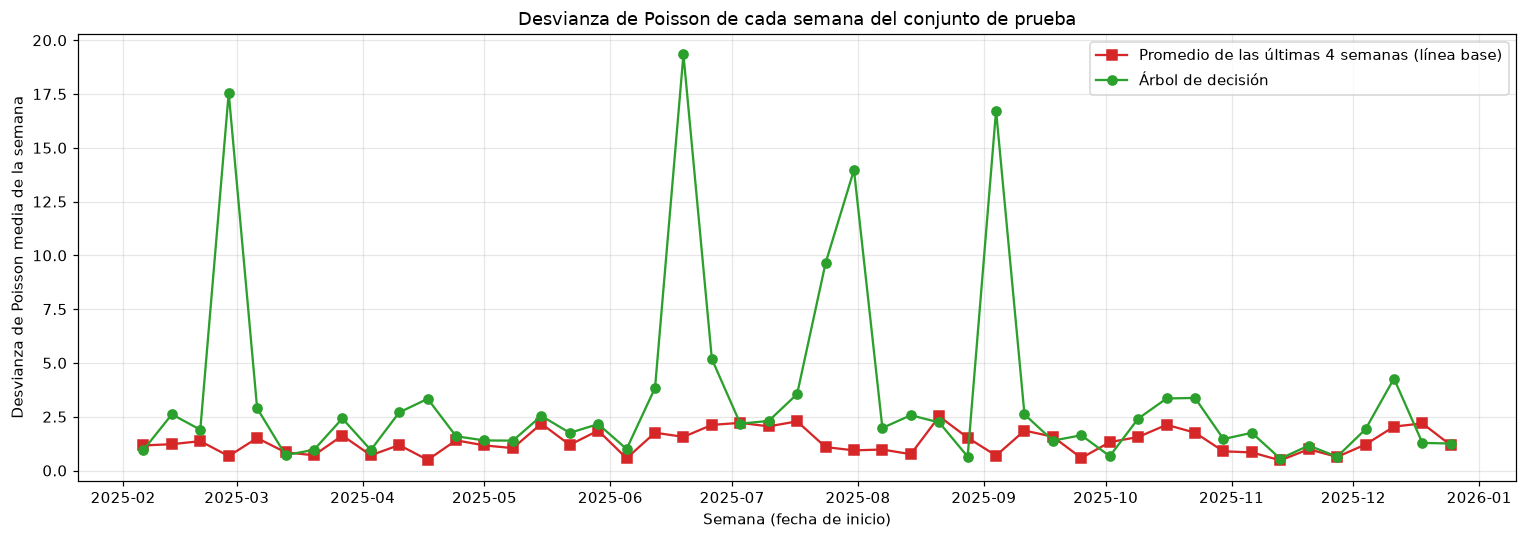

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fechas_semanas, semanal[f"desvianza | {LINEA_BASE}"], marker="s", color="tab:red", label=LINEA_BASE)
ax.plot(fechas_semanas, semanal[f"desvianza | {ARBOL}"], marker="o", color="tab:green", label=ARBOL)

ax.set_title("Desvianza de Poisson de cada semana del conjunto de prueba")
ax.set_xlabel("Semana (fecha de inicio)")
ax.set_ylabel("Desvianza de Poisson media de la semana")
ax.legend()
plt.tight_layout()
guardar_figura(fig, "fig4_test_desvianza_semanal.png")
plt.show()

**Lectura** (tablas `05_test_metricas`, `06_test_semanal` y `07_test_variabilidad_semanal`; figuras
`fig3_test_totales_semanales` y `fig4_test_desvianza_semanal`; celda de días con predicción 0).

| Modelo | Desvianza de Poisson | Diferencia con la línea base | MAE | Total predicho / observado | Días con predicción 0 |
| --- | --- | --- | --- | --- | --- |
| Media constante | **1,262** | −5,2 % | **1,741** | 0,884 | 0 |
| **Promedio de las últimas 4 semanas (línea base)** | 1,332 | — | 1,755 | **0,981** | 0 |
| Árbol de decisión | 3,462 | +159,9 % | 2,137 | 0,967 | 7 |
| Repetir semana anterior | 5,007 | +275,8 % | 2,228 | 0,996 | 10 |

- **Con la métrica principal, la media constante es la mejor:** desvianza 1,262 contra 1,332 de la
  línea base, un 5,2 % menos. Le gana a la línea base en 29 de las 47 semanas. Con MAE la diferencia
  era chica (0,8 %); con la desvianza es mayor.
- **Pero la línea base sigue el volumen y la media constante no.** La línea base predice el 98,1 % de
  los siniestros ocurridos; la media constante, el 88,4 %, porque aprendió el nivel de entrenamiento
  (3,426 por día) y la prueba promedia 3,875. En la figura 3, la línea base va de 17,25 siniestros por
  semana (semana del 20/2) a 32,5 (semana del 9/10); la media constante predice 23,98 todas las semanas.
- **El árbol es mucho peor:** desvianza 3,462, un 159,9 % más que la línea base. Le gana a la línea
  base en 8 de las 47 semanas.
- **Buena parte de esa diferencia viene de pocos días.** El árbol predijo exactamente 0 en 7 días, y
  en 5 hubo siniestros (celda de arriba). Las semanas que contienen esos 5 días son los picos de la
  figura 4: desvianza semanal de 17,55 (semana del 27/2), 19,34 (19/6), 9,64 (24/7), 13,97 (31/7) y
  16,73 (4/9). Fuera de esos picos, el árbol queda más cerca de la línea base, aunque casi siempre por
  encima.
- **Repetir la semana anterior es la peor** (5,007): copia los días sin siniestros de la semana
  anterior, y predijo 0 en 10 días.
- **Una semana no alcanzaba.** En la primera semana el árbol tenía la menor desvianza (0,957); en las
  47 semanas queda tercero. Su desvianza semanal va de 0,55 a 19,34; la de la línea base, de 0,47 a 2,52.
- **Control:** la media constante da la misma desvianza y el mismo MAE que en `base.ipynb` (1,2620
  contra 1,2625, y 1,7410 contra 1,7411): métricas y evaluación se calculan igual en los dos notebooks.

> **Sobre la línea base.** Se eligió en la sección 5, antes de mirar la prueba, y no se cambia. Con la
> métrica principal la media constante es un 5,2 % mejor: si se quiere revisar la línea base, hay que
> hacerlo con datos de validación (Entregable 3), no con la prueba.

## 8. Conclusiones

**Lo que muestran los datos** (evidencia):

1. Con la métrica principal (desvianza de Poisson media), en todo el conjunto de prueba: media
   constante **1,262**, línea base **1,332**, árbol de decisión **3,462** y repetir la semana anterior
   **5,007**. **El árbol no mejora a las referencias simples.**
2. La media constante tiene menos desvianza que la línea base (−5,2 %), pero la línea base acierta
   mejor el volumen: predice el 98,1 % del total, contra el 88,4 %.
3. Buena parte de la desvianza del árbol viene de 7 días en que predijo exactamente 0; en 5 de ellos
   hubo siniestros. Además, el árbol **memoriza**: 716 hojas para 1.295 filas de entrenamiento.
4. Evaluar una sola semana es engañoso: en la primera, el árbol tenía la menor desvianza (0,957); en
   las 47 semanas queda tercero.
5. La desvianza y el MAE no siempre ordenan igual a los modelos (primera semana).

**Lo que concluye el equipo** (inferencia):

- Los resultados sugieren que los días anteriores traen poca información para un árbol. Coincide con
  el diagnóstico: las autocorrelaciones de la serie son débiles (la más alta, 0,1706).
- Un árbol con hojas de uno o dos días puede predecir 0 copiando un día puntual del pasado, y la métrica
  principal lo castiga fuerte. Limitar la profundidad o exigir un mínimo de días por hoja debería evitar
  esas predicciones: es una hipótesis para probar con validación.
- Seguir el nivel reciente mejora el volumen total, pero no la desvianza: promediar solo cuatro días de
  semanas anteriores también arrastra ruido.
- Para el Entregable 3: elegir la profundidad del árbol con validación y con la desvianza de Poisson como
  criterio, revisar con validación la ventana de la línea base, y recién después sumar variables
  exógenas (calendario, clima) para medir cuánto agregan sobre esta base sin exógenas.

**Límites:** un solo municipio, un solo horizonte (7 días) y rezagos apoyados en un diagnóstico que miró
la serie completa. Nada de esto permite afirmar cómo funciona el modelo en el resto de Montevideo.